In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.to_csv("titanic.csv",index = False )

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.shape

(891, 15)

In [12]:
df_check = pd.read_csv("titanic.csv")
df_check.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
missing_percent = df.isnull().mean() * 100
missing_percent

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


In [17]:
df = df.drop(columns=["deck"])

In [19]:
df = df.dropna(subset=["embarked", "embark_town"])

In [20]:
df["age"].fillna(df["age"].median(),inplace = True)

/tmp/ipykernel_6140/3479368497.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(),inplace = True)
/tmp/ipykernel_6140/3479368497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"].fillna(df["age"].median(),inplace = True)


In [21]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [22]:
df.to_csv("titanic_cleaned.csv",index = False)

In [23]:
import matplotlib.pyplot as plt



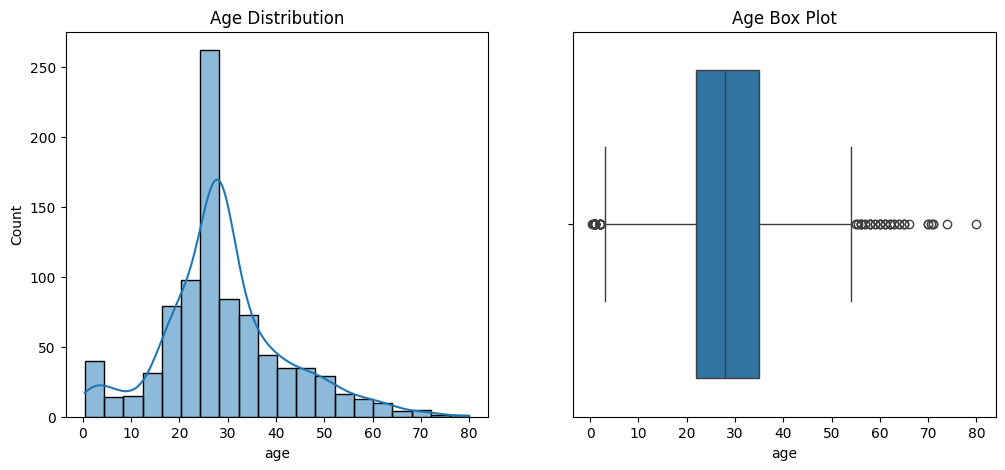

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df['age'])
plt.title('Age Box Plot')

plt.show()


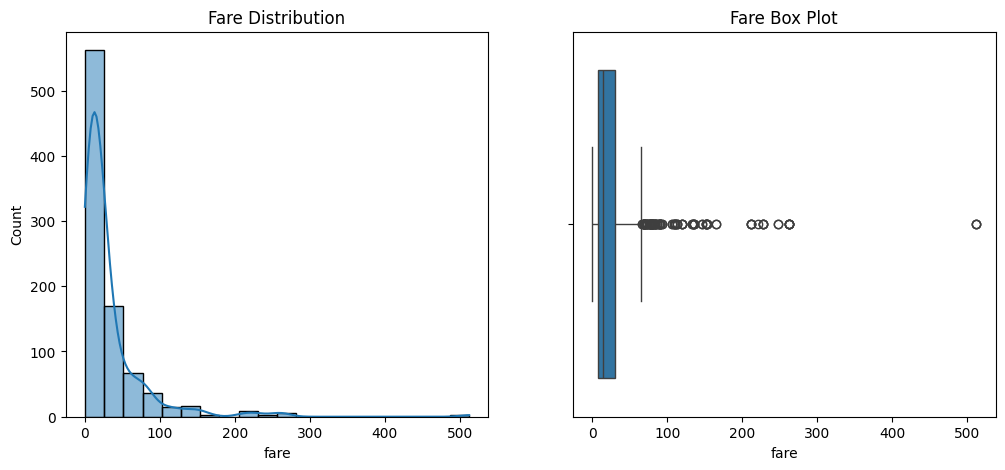

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['fare'], bins=20, kde=True)
plt.title('Fare Distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df['fare'])
plt.title('Fare Box Plot')

plt.show()


In [26]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

age_outliers, age_lower, age_upper = count_outliers(df['age'])
fare_outliers, fare_lower, fare_upper = count_outliers(df['fare'])

print(f"Age outliers: {age_outliers}")
print(f"Fare outliers: {fare_outliers}")


Age outliers: 65
Fare outliers: 114


In [27]:
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]

print(f"Mean: {fare_mean:.2f}, Median: {fare_median:.2f}, Mode: {fare_mode:.2f}")


Mean: 32.10, Median: 14.45, Mode: 8.05


In [28]:
survival_by_sex = df.groupby('sex')['survived'].mean() * 100
print("Survival rate by sex (%):")
print(survival_by_sex)


Survival rate by sex (%):
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


In [29]:
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
print("\nSurvival rate by passenger class (%):")
print(survival_by_class)



Survival rate by passenger class (%):
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [30]:
survival_by_sex_class = df.groupby(['sex', 'pclass'])['survived'].mean() * 100
print("\nSurvival rate by sex and class (%):")
print(survival_by_sex_class)



Survival rate by sex and class (%):
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [31]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)


          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


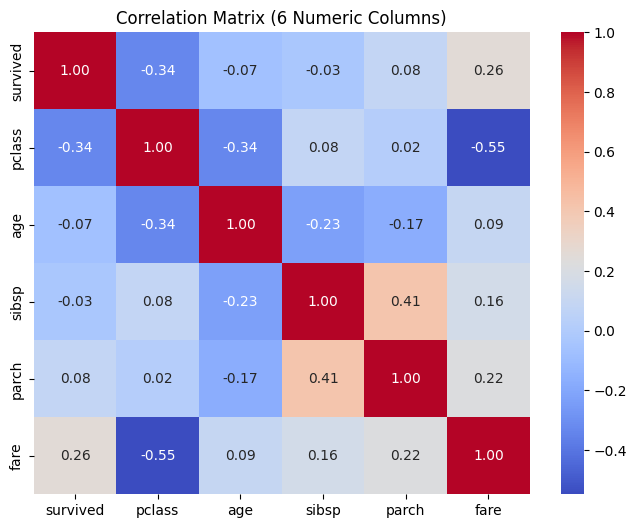

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (6 Numeric Columns)')
plt.show()


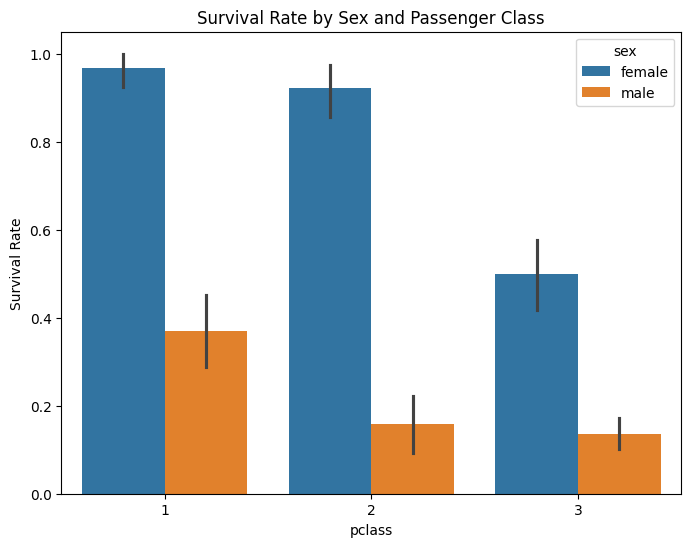

In [33]:
plt.figure(figsize=(8,6))
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival Rate by Sex and Passenger Class')
plt.ylabel('Survival Rate')
plt.show()


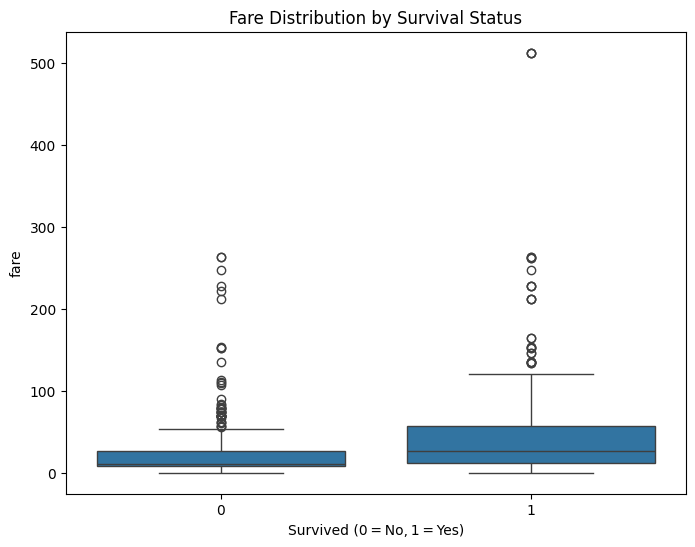

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.show()


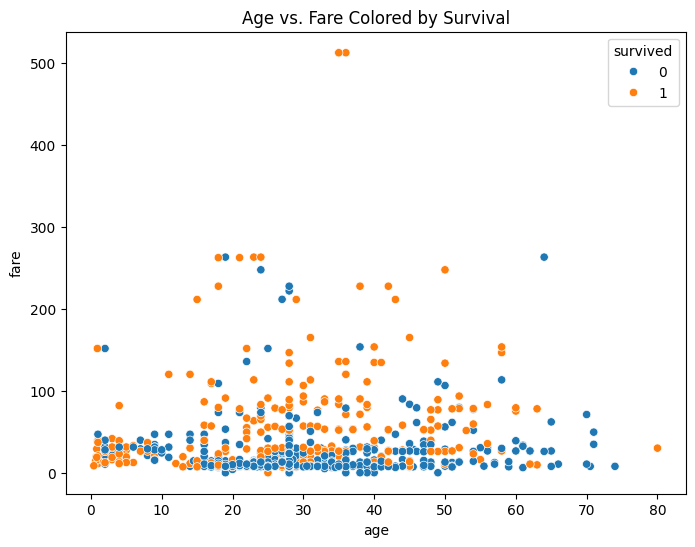

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Age vs. Fare Colored by Survival')
plt.show()


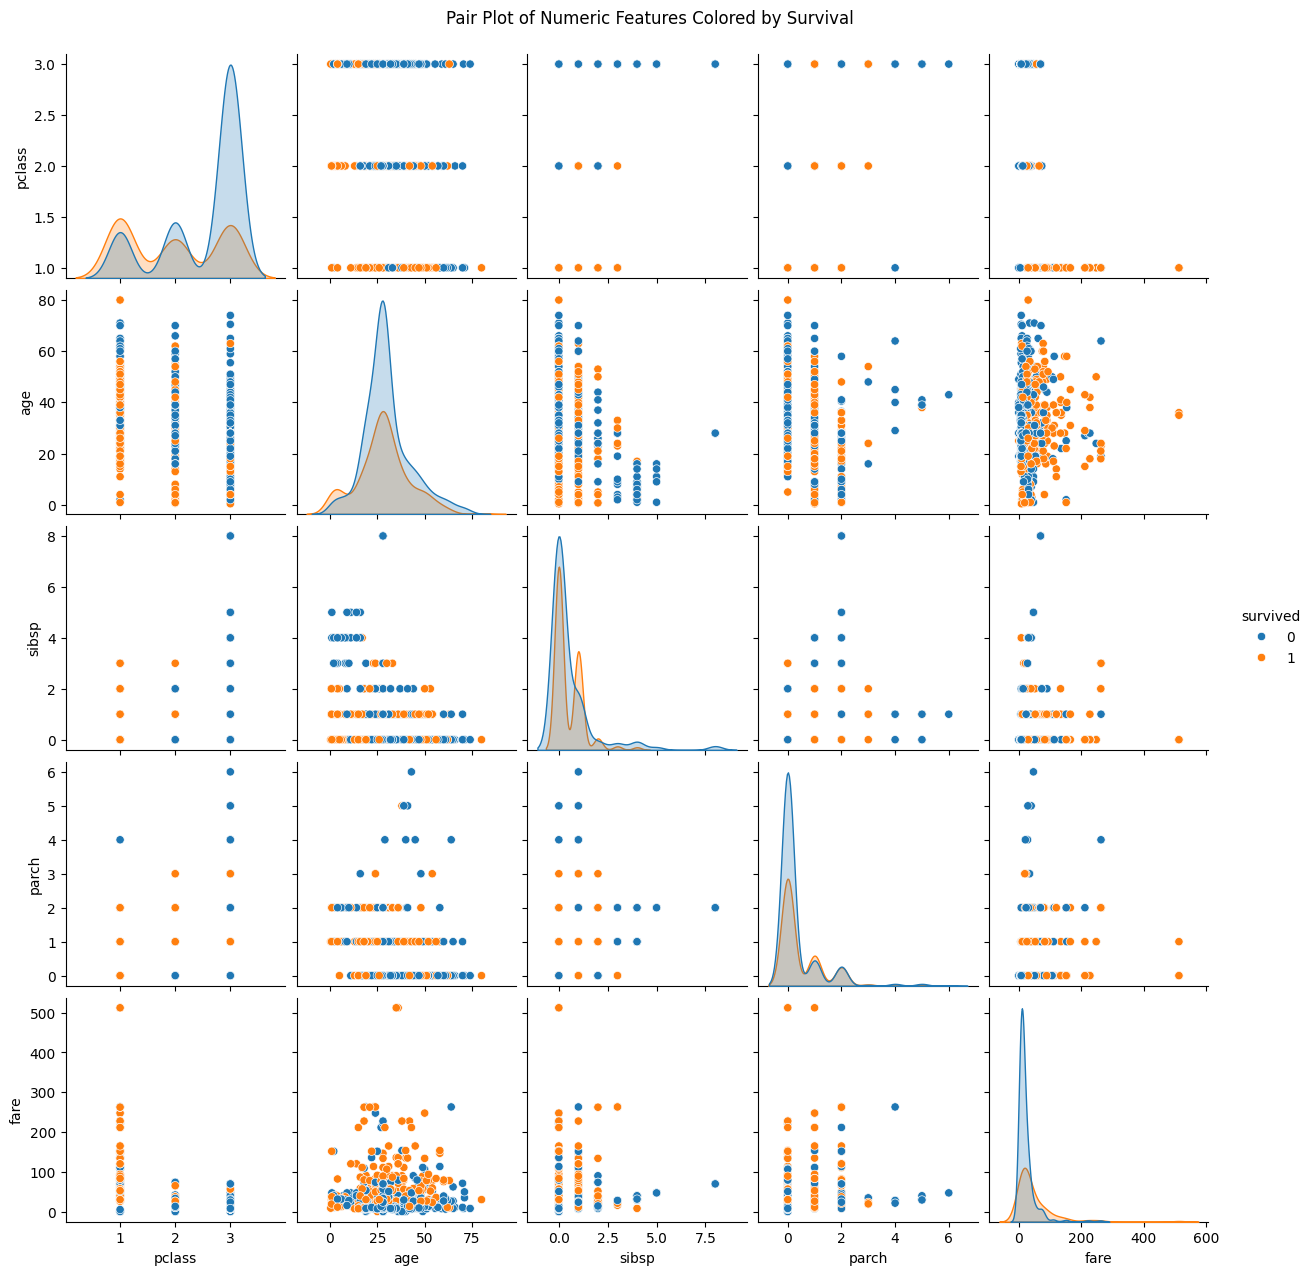

In [36]:
sns.pairplot(df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']], hue='survived')
plt.suptitle('Pair Plot of Numeric Features Colored by Survival', y=1.02)
plt.show()


In [37]:
from sklearn.preprocessing import StandardScaler


In [38]:
print("Before standardization:")
print(df[['age', 'fare']].mean())
print(df[['age', 'fare']].std())


Before standardization:
age     29.315152
fare    32.096681
dtype: float64
age     12.984932
fare    49.697504
dtype: float64


In [39]:
scaler = StandardScaler()
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])


/tmp/ipykernel_6140/3551212168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])
/tmp/ipykernel_6140/3551212168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])


In [40]:
print("\nAfter standardization:")
print(df[['age_scaled', 'fare_scaled']].mean())
print(df[['age_scaled', 'fare_scaled']].std())



After standardization:
age_scaled     2.717486e-16
fare_scaled    1.398706e-16
dtype: float64
age_scaled     1.000563
fare_scaled    1.000563
dtype: float64


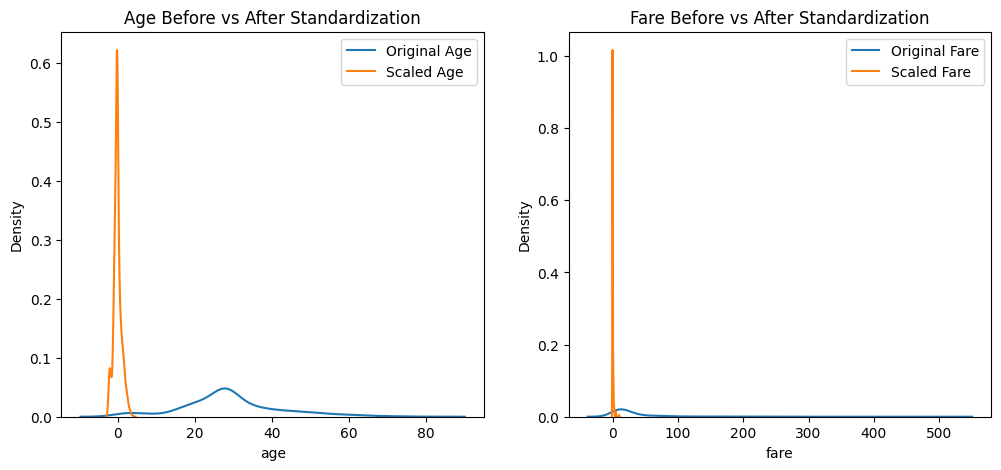

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(df['age'], label='Original Age')
sns.kdeplot(df['age_scaled'], label='Scaled Age')
plt.title('Age Before vs After Standardization')
plt.legend()

plt.subplot(1,2,2)
sns.kdeplot(df['fare'], label='Original Fare')
sns.kdeplot(df['fare_scaled'], label='Scaled Fare')
plt.title('Fare Before vs After Standardization')
plt.legend()

plt.show()


Exploratory standardization check  
The age and fare columns were standardized using the z‑score formula.
After transformation, both have mean ≈ 0 and standard deviation ≈ 1, confirming successful scaling.
This check ensures numeric features are on comparable scales before modeling, though the actual pipeline will re‑fit scaling on the training data only.